In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers

In [2]:
# Turn off the solver's verbose output
solvers.options['show_progress'] = False

class CBFController:
    def __init__(self, obs_center, obs_radius, gamma=1.0):
        self.obs_center = np.array(obs_center)
        self.obs_radius = obs_radius
        self.gamma = gamma  # Aggressiveness of the barrier

    def get_safe_control(self, robot_state, u_nominal):
        """
        Solves the QP to find the closest safe control to u_nominal.
        
        Args:
            robot_state: np.array([x, y])
            u_nominal: np.array([vx, vy]) - Desired velocity
            
        Returns:
            u_safe: np.array([vx, vy]) - Safe velocity
        """
        x = robot_state
        
        # 1. Calculate Barrier Function h(x)
        # h(x) = ||x - x_obs||^2 - r^2
        # h >= 0 means safe
        diff = x - self.obs_center
        dist_sq = np.dot(diff, diff)
        h = dist_sq - self.obs_radius**2

        # 2. Calculate the Gradient of h(x) (Lg_h)
        # grad_h = 2 * (x - x_obs)
        # h_dot = grad_h * u
        grad_h = 2 * diff

        # 3. Setup the Quadratic Program (QP)
        # Minimize: 0.5 * ||u - u_nom||^2
        # Subject to: grad_h * u >= -gamma * h(x)
        
        # Standard QP form: min (1/2)x'Px + q'x  s.t. Gx <= h_qp
        
        # P matrix (Identity matrix for minimizing perturbation)
        P = matrix(np.eye(2), tc='d')
        
        # q vector (-u_nominal to match the (u - u_nom)^2 expansion)
        q = matrix(-u_nominal, tc='d')
        
        # G matrix (The constraint LHS). Note the negative sign!
        # We need: grad_h * u >= -gamma * h
        # Becomes: -grad_h * u <= gamma * h
        G = matrix(-grad_h.reshape(1, 2), tc='d')
        
        # h_qp vector (The constraint RHS)
        h_qp = matrix(np.array([self.gamma * h]), tc='d')

        try:
            # Solve the QP
            sol = solvers.qp(P, q, G, h_qp)
            u_safe = np.array(sol['x']).flatten()
            return u_safe
        except ValueError:
            # If infeasible (e.g., starting inside obstacle), stop!
            print("QP Infeasible! Stopping robot.")
            return np.array([0.0, 0.0])

def run_simulation(start_pos = np.array([0.0, 0.0]), goal_pos = np.array([10.0, 9.5]), gamma = 0.5):
    # Simulation Parameters
    
    obs_pos = np.array([5.0, 5.0])
    obs_radius = 2.0
    dt = 0.05
    steps = 500

    controller = CBFController(obs_pos, obs_radius, gamma=gamma)
    
    # Logs for plotting
    trajectory = [start_pos.copy()]
    controls = []
    
    current_pos = start_pos.copy()

    print("Starting Simulation...")
    for i in range(steps):
        # 1. Nominal Controller (Proportional / "Go to Goal")
        # Simple P-controller: u = Kp * (goal - x)
        Kp = 1.0
        u_nom = Kp * (goal_pos - current_pos)
        
        # Clip max speed to make it realistic
        speed_limit = 2.0
        if np.linalg.norm(u_nom) > speed_limit:
            u_nom = u_nom / np.linalg.norm(u_nom) * speed_limit

        # 2. Apply Safety Filter (CBF)
        u_safe = controller.get_safe_control(current_pos, u_nom)
        
        # 3. Integrate Dynamics (Euler Integration)
        # x_next = x + u * dt
        current_pos = current_pos + u_safe * dt
        
        # Logging
        trajectory.append(current_pos.copy())
        controls.append(u_safe.copy())
        
        # Check if reached goal
        if np.linalg.norm(current_pos - goal_pos) < 0.1:
            print(f"Goal Reached at step {i}!")
            break

    # Visualization
    trajectory = np.array(trajectory)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Plot Trajectory
    ax.plot(trajectory[:, 0], trajectory[:, 1], 'b-', linewidth=2, label='Robot Path')
    ax.plot(start_pos[0], start_pos[1], 'go', label='Start')
    ax.plot(goal_pos[0], goal_pos[1], 'g*', markersize=12, label='Goal')

    # Plot Obstacle
    # We plot the "safe boundary" (radius)
    circle = plt.Circle(obs_pos, obs_radius, color='r', alpha=0.3, label='Obstacle')
    ax.add_patch(circle)
    # Plot the center
    ax.plot(obs_pos[0], obs_pos[1], 'rx')

    # Formatting
    ax.set_aspect('equal')
    ax.set_xlim(-1, 12)
    ax.set_ylim(-1, 12)
    ax.legend()
    ax.grid(True)
    ax.set_title("CBF Safety Filter: Single Integrator")
    
    plt.show()

Starting Simulation...


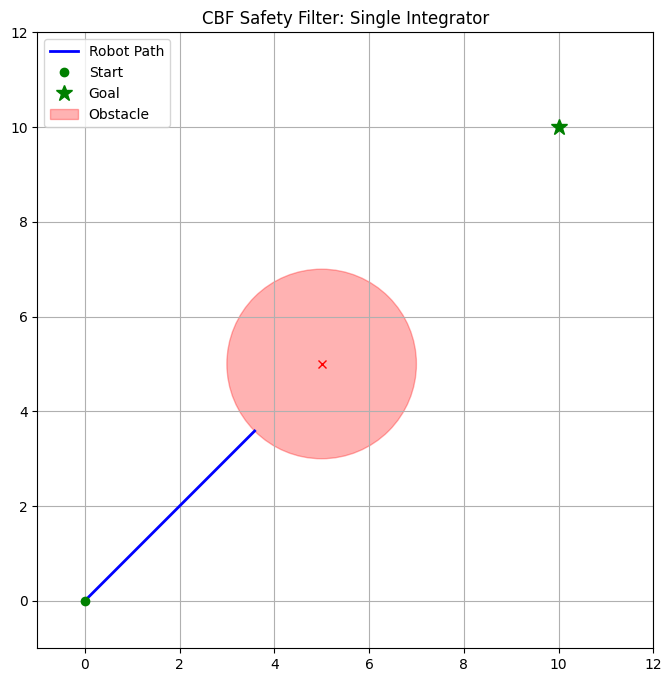

Starting Simulation...
Goal Reached at step 274!


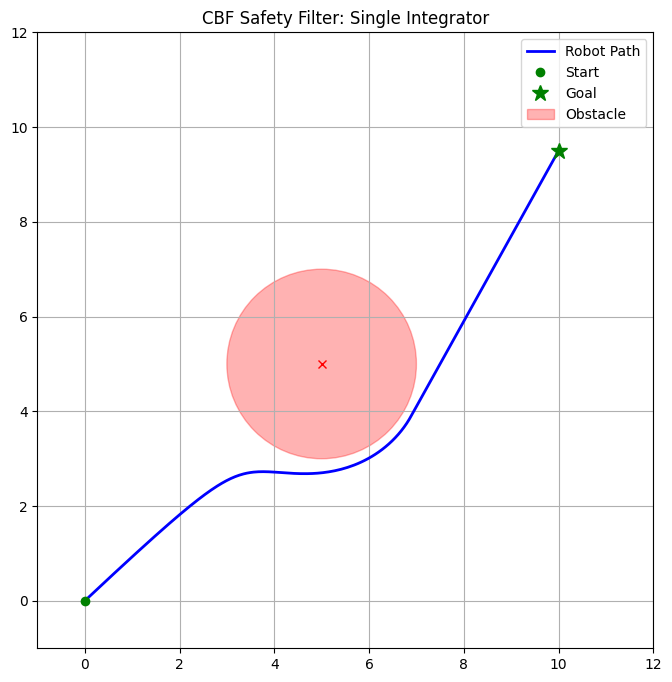

In [3]:
run_simulation(start_pos = np.array([0.0, 0.0]), goal_pos = np.array([10.0, 10.0]))
run_simulation()

In [4]:
# Turn off the solver's verbose output
solvers.options['show_progress'] = False

import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers

# Turn off the solver's verbose output
solvers.options['show_progress'] = False

class CBFController:
    def __init__(self, obs_center, obs_radius, gamma=1.0):
        self.obs_center = np.array(obs_center)
        self.obs_radius = obs_radius
        self.gamma = gamma
        self.prev_u = np.array([0.0, 0.0]) # Track previous direction for sliding

    def get_safe_control(self, robot_state, u_nominal):
        x = robot_state
        
        # 1. Calculate Barrier Function h(x)
        diff = x - self.obs_center
        dist = np.linalg.norm(diff)
        h = dist**2 - self.obs_radius**2

        # 2. Calculate the Gradient (Normal vector pointing out)
        grad_h = 2 * diff
        
        # --- NEW LOGIC: Perpendicular Slide Check ---
        # Normalize vectors for angle comparison
        norm_grad = grad_h / (np.linalg.norm(grad_h) + 1e-6)
        norm_u_nom = u_nominal / (np.linalg.norm(u_nominal) + 1e-6)
        
        # dot_product = cos(theta). If near 0, vectors are perpendicular.
        # If near -1, robot is heading head-on into the obstacle.
        dot_product = np.dot(norm_u_nom, norm_grad)

        # Trigger slide if we are close to the boundary AND heading into/tangent to it
        if h < 1.0 and dot_product < 0.1:
            # Calculate the two possible perpendicular tangents to the circle
            tangent1 = np.array([-norm_grad[1], norm_grad[0]]) # Counter-clockwise
            tangent2 = np.array([norm_grad[1], -norm_grad[0]]) # Clockwise
            
            # Choose the tangent closest to our previous direction (prevents oscillating)
            if np.dot(tangent1, self.prev_u) >= np.dot(tangent2, self.prev_u):
                # Replace u_nominal with a slide along the surface
                u_nominal = tangent1 * np.linalg.norm(u_nominal)
            else:
                u_nominal = tangent2 * np.linalg.norm(u_nominal)

        # 3. Setup the Quadratic Program (QP)
        P = matrix(np.eye(2), tc='d')
        q = matrix(-u_nominal, tc='d')
        G = matrix(-grad_h.reshape(1, 2), tc='d')
        h_qp = matrix(np.array([self.gamma * h]), tc='d')

        try:
            sol = solvers.qp(P, q, G, h_qp)
            u_safe = np.array(sol['x']).flatten()
            self.prev_u = u_safe # Store for next step
            return u_safe
        except ValueError:
            return np.array([0.0, 0.0])

# run_simulation stays the same as your provided code...

def run_simulation(start_pos = np.array([0.0, 0.0]), goal_pos = np.array([10.0, 9.5]), gamma = 0.5):
    # Simulation Parameters
    obs_pos = np.array([5.0, 5.0])
    obs_radius = 2.0
    dt = 0.05
    steps = 500

    controller = CBFController(obs_pos, obs_radius, gamma)
    
    # Logs for plotting
    trajectory = [start_pos.copy()]
    controls = []
    
    current_pos = start_pos.copy()

    print("Starting Simulation...")
    for i in range(steps):
        # 1. Nominal Controller (Proportional / "Go to Goal")
        # Simple P-controller: u = Kp * (goal - x)
        Kp = 1.0
        u_nom = Kp * (goal_pos - current_pos)
        
        # Clip max speed to make it realistic
        speed_limit = 2.0
        if np.linalg.norm(u_nom) > speed_limit:
            u_nom = u_nom / np.linalg.norm(u_nom) * speed_limit

        # 2. Apply Safety Filter (CBF)
        u_safe = controller.get_safe_control(current_pos, u_nom)
        
        # 3. Integrate Dynamics (Euler Integration)
        # x_next = x + u * dt
        current_pos = current_pos + u_safe * dt
        
        # Logging
        trajectory.append(current_pos.copy())
        controls.append(u_safe.copy())
        
        # Check if reached goal
        if np.linalg.norm(current_pos - goal_pos) < 0.1:
            print(f"Goal Reached at step {i}!")
            break

    # Visualization
    trajectory = np.array(trajectory)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Plot Trajectory
    ax.plot(trajectory[:, 0], trajectory[:, 1], 'b-', linewidth=2, label='Robot Path')
    ax.plot(start_pos[0], start_pos[1], 'go', label='Start')
    ax.plot(goal_pos[0], goal_pos[1], 'g*', markersize=12, label='Goal')

    # Plot Obstacle
    # We plot the "safe boundary" (radius)
    circle = plt.Circle(obs_pos, obs_radius, color='r', alpha=0.3, label='Obstacle')
    ax.add_patch(circle)
    # Plot the center
    ax.plot(obs_pos[0], obs_pos[1], 'rx')

    # Formatting
    ax.set_aspect('equal')
    ax.set_xlim(-1, 12)
    ax.set_ylim(-1, 12)
    ax.legend()
    ax.grid(True)
    ax.set_title("CBF Safety Filter: Single Integrator")
    
    plt.show()

Starting Simulation...
Goal Reached at step 305!


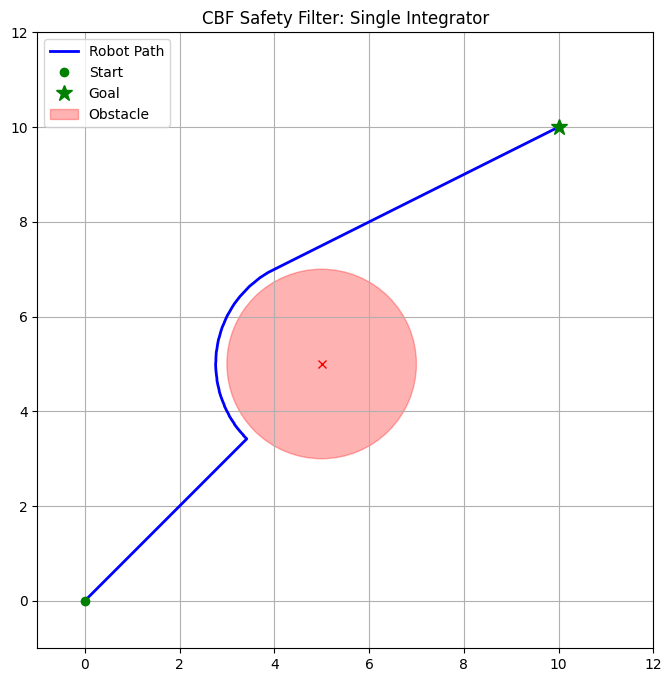

Starting Simulation...
Goal Reached at step 273!


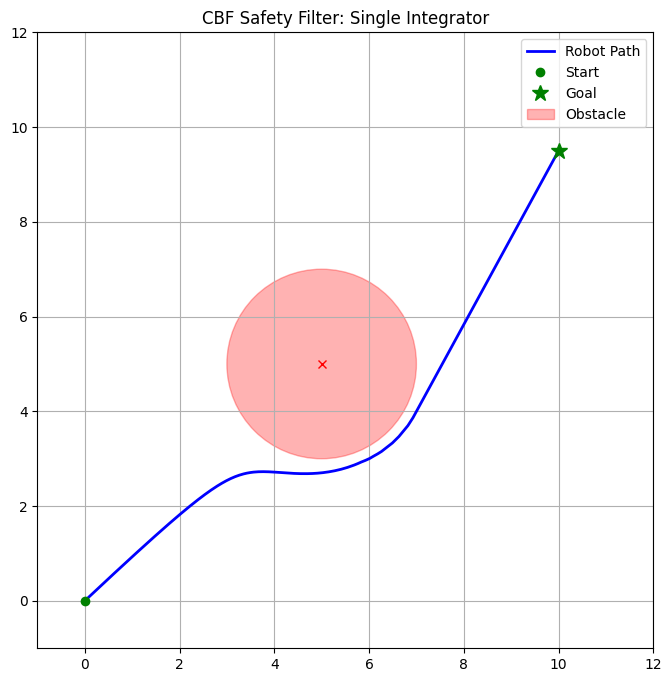

In [5]:
run_simulation(start_pos = np.array([0.0, 0.0]), goal_pos = np.array([10.0, 10.0]), gamma = 0.5)
run_simulation()

In [6]:
# Turn off solver verbose output
solvers.options['show_progress'] = False

import numpy as np
from cvxopt import matrix, solvers

# Turn off solver verbose output
solvers.options['show_progress'] = False

class HOCBF_Circle_Controller:
    def __init__(self, obs_center, obs_radius, alpha_1 = 1.0, alpha_2 = 2.0):
        self.obs_center = np.array(obs_center)
        self.obs_radius = obs_radius
        
        # Hyperparameters (UNCHANGED as requested)
        self.alpha1 = alpha_1
        self.alpha2 = alpha_2  

    def get_control(self, state, u_nom):
        p = state[:2]
        v = state[2:]
        
        # --- Step 1: Barrier Function & Gradient ---
        diff = p - self.obs_center
        dist_sq = np.dot(diff, diff)
        h = dist_sq - self.obs_radius**2
        grad_h_p = 2 * diff  
        h_dot = np.dot(grad_h_p, v)

        # --- NEW LOGIC: Tangential Redirection ---
        # Normalize for geometry check
        norm_v = v / (np.linalg.norm(v) + 1e-6)
        norm_grad = grad_h_p / (np.linalg.norm(grad_h_p) + 1e-6)
        
        # Check if perpendicularity check is needed: 
        # If robot is close and velocity is heading into the obstacle
        if h < 1.0 and np.dot(norm_v, norm_grad) < 0.1:
            # Calculate two possible perpendicular directions (tangents)
            tangent1 = np.array([-norm_grad[1], norm_grad[0]])
            tangent2 = np.array([norm_grad[1], -norm_grad[0]])
            
            # Choose the direction that aligns with the current velocity
            if np.dot(tangent1, norm_v) > np.dot(tangent2, norm_v):
                slide_dir = tangent1
            else:
                slide_dir = tangent2
            
            # Redirect u_nom to be parallel to the surface
            u_nom = slide_dir * np.linalg.norm(u_nom)
        
        # --- Step 2: HOCBF Constraints ---
        psi1 = h_dot + self.alpha1 * h
        Lf_h_dot = 2 * np.dot(v, v)
        Lg_h_dot = grad_h_p
        
        # --- Step 3: QP Formulation ---
        P = matrix(np.eye(2), tc='d')
        q = matrix(-u_nom, tc='d')
        
        G = matrix(-Lg_h_dot.reshape(1, 2), tc='d')
        rhs_val = Lf_h_dot + self.alpha1 * h_dot + self.alpha2 * psi1
        h_qp = matrix(np.array([rhs_val]), tc='d')
        
        try:
            sol = solvers.qp(P, q, G, h_qp)
            return np.array(sol['x']).flatten()
        except ValueError:
            return -2.0 * v

def run_simulation(start_state = np.array([0.0, 0.0, 3.0, 3.0]), goal_pos = np.array([10.0, 9.5]), alpha_1 = 1.0, alpha_2 = 2.0):
    # Setup: Start with high initial velocity to test momentum handling
     
    # Obstacle in the middle
    obs_pos = np.array([5.0, 5.0])
    obs_radius = 2.0
    
    controller = HOCBF_Circle_Controller(obs_pos, obs_radius, alpha_1, alpha_2)
    
    dt = 0.05
    steps = 200
    state = start_state.copy()
    
    traj = [state[:2].copy()]
    
    print("Running HOCBF Circle Simulation...")
    for i in range(steps):
        p = state[:2]
        v = state[2:]
        
        # 1. Nominal Control (PD Controller for double integrator)
        # u_nom = Kp * error_p + Kd * error_v
        Kp, Kd = 2.0, 3.0
        u_nom = Kp * (goal_pos - p) + Kd * (np.array([0,0]) - v)
        
        # Clip max acceleration for realism
        acc_limit = 8.0
        if np.linalg.norm(u_nom) > acc_limit:
            u_nom = u_nom / np.linalg.norm(u_nom) * acc_limit
            
        # 2. HOCBF Safety Filter
        u_safe = controller.get_control(state, u_nom)
        
        # 3. Integrate (Double Integrator Physics)
        # p_next = p + v*dt + 0.5*u*dt^2
        # v_next = v + u*dt
        state[:2] += state[2:] * dt + 0.5 * u_safe * dt**2
        state[2:] += u_safe * dt
        
        traj.append(state[:2].copy())
        
        if np.linalg.norm(state[:2] - goal_pos) < 0.2:
            print("Goal reached!")
            break
            
    # Plotting
    traj = np.array(traj)
    fig, ax = plt.subplots(figsize=(6, 6))
    circle = plt.Circle(obs_pos, obs_radius, color='r', alpha=0.3)
    ax.add_patch(circle)
    ax.plot(traj[:, 0], traj[:, 1], 'b-', linewidth=2, label="HOCBF Trajectory")
    ax.plot(start_state[0], start_state[1], 'go', label="Start")
    ax.plot(goal_pos[0], goal_pos[1], 'g*', label="Goal")
    ax.set_title("HOCBF (Momentum Aware) - Circle")
    ax.set_xlim(-1, 12)
    ax.set_ylim(-1, 12)
    ax.grid(True)
    ax.legend()
    plt.show()


Running HOCBF Circle Simulation...
Goal reached!


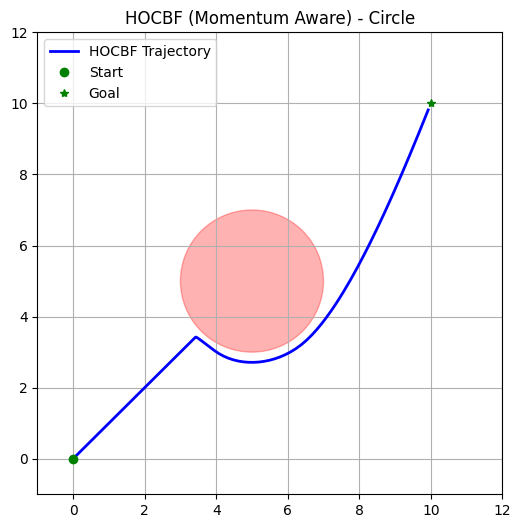

Running HOCBF Circle Simulation...
Goal reached!


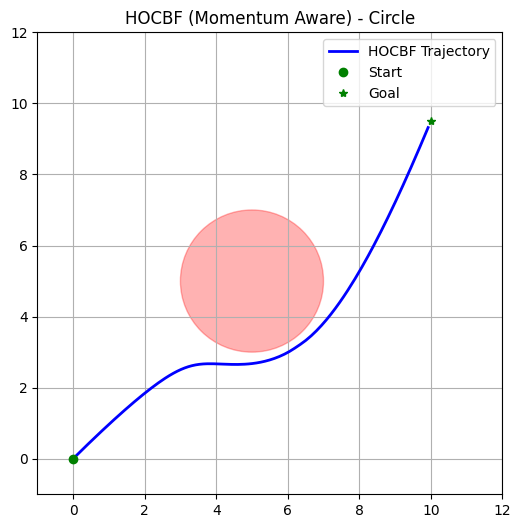

In [7]:
run_simulation(start_state = np.array([0.0, 0.0, 3.0, 3.0]), goal_pos = np.array([10.0, 10.0]))
run_simulation()